# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** I Wayan Mulawarman Restumurti
- **Email:** iwayanrestumurti33@gmail.com
- **ID Dicoding:** iwayanrestu

## Menentukan Pertanyaan Bisnis

- Kategori produk apa yang paling berkontribusi terhadap revenue?
- Bagaimana performa pengiriman dan apakah banyak keterlambatan?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import zipfile
import os

## Data Wrangling

### Gathering Data

In [2]:
uploaded = files.upload()

Saving data.zip to data.zip


In [3]:
zip_path = "data.zip"
extract_path = "data"

# Buat folder tujuan
os.makedirs(extract_path, exist_ok=True)

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Ekstraksi selesai!")

Ekstraksi selesai!


In [4]:
os.listdir("data")

['products_dataset.csv',
 'order_reviews_dataset.csv',
 'New Text Document.txt',
 'order_items_dataset.csv',
 'order_payments_dataset.csv',
 'orders_dataset.csv',
 'geolocation_dataset.csv',
 'customers_dataset.csv',
 'product_category_name_translation.csv',
 'sellers_dataset.csv']

In [5]:
# Load dataset
customers = pd.read_csv('data/customers_dataset.csv')
orders = pd.read_csv('data/orders_dataset.csv')
order_items = pd.read_csv('data/order_items_dataset.csv')
products = pd.read_csv('data/products_dataset.csv')
payments = pd.read_csv('data/order_payments_dataset.csv')
reviews = pd.read_csv('data/order_reviews_dataset.csv')
sellers = pd.read_csv('data/sellers_dataset.csv')
geo = pd.read_csv('data/geolocation_dataset.csv')
category = pd.read_csv('data/product_category_name_translation.csv')

In [6]:
#Gabungkan Dataset
df = pd.merge(orders, customers, on='customer_id', how='left')
df = pd.merge(df, order_items, on='order_id', how='left')
df = pd.merge(df, products, on='product_id', how='left')
df = pd.merge(df, payments, on='order_id', how='left')
df = pd.merge(df, category, on='product_category_name', how='left')

In [7]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,18.12,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,2.00,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,18.59,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,141.46,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,420.0,24.0,19.0,21.0,1.0,credit_card,3.0,179.12,auto


In [8]:
df.to_csv('main_data.csv', index=False)

**Insight:**
- Satu order bisa memiliki beberapa metode pembayaran, Contoh pada order_id = e481f51cbdc54678b7cc49136f2d6af7 Terdapat 3 baris berbeda untuk 1 order yang sama
- Pengiriman cenderung lebih cepat dari estimasi

### Assessing Data

In [9]:
df = pd.read_csv('main_data.csv')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,18.12,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,2.00,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,18.59,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,141.46,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,420.0,24.0,19.0,21.0,1.0,credit_card,3.0,179.12,auto


In [10]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 31 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118434 non-null  object 
 1   customer_id                    118434 non-null  object 
 2   order_status                   118434 non-null  object 
 3   order_purchase_timestamp       118434 non-null  object 
 4   order_approved_at              118258 non-null  object 
 5   order_delivered_carrier_date   116360 non-null  object 
 6   order_delivered_customer_date  115037 non-null  object 
 7   order_estimated_delivery_date  118434 non-null  object 
 8   customer_unique_id             118434 non-null  object 
 9   customer_zip_code_prefix       118434 non-null  int64  
 10  customer_city                  118434 non-null  object 
 11  customer_state                 118434 non-null  object 
 12  order_item_id                 

In [12]:
df.describe()
df.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,product_category_name_english
count,118434,118434,118434,118434,118258,116360,115037,118434,118434,118434.000000,...,115906.000000,117584.000000,117584.000000,117584.00000,117584.000000,118431.000000,118431,118431.000000,118431.000000,115881
unique,99441,99441,8,98875,90733,81018,95664,459,96096,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,NaN,71
top,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,2017-08-08 20:26:31,2017-08-08 20:43:31,2017-08-10 11:58:14,2017-08-14 12:46:18,2017-12-20 00:00:00,9a736b248f67d166d2fbb006bcb877c3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,credit_card,NaN,NaN,bed_bath_table
freq,63,63,115038,63,63,63,63,656,75,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,87286,NaN,NaN,11823
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35034.264392,...,2.207849,2114.281067,30.256872,16.63029,23.068394,1.094207,NaN,2.937398,172.849395,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29819.290218,...,1.719519,3788.754048,16.190874,13.45878,11.748372,0.728290,NaN,2.774164,268.259831,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1003.000000,...,1.000000,0.000000,7.000000,2.00000,6.000000,1.000000,NaN,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11310.000000,...,1.000000,300.000000,18.000000,8.00000,15.000000,1.000000,NaN,1.000000,60.860000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24240.000000,...,1.000000,700.000000,25.000000,13.00000,20.000000,1.000000,NaN,2.000000,108.200000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58464.500000,...,3.000000,1800.000000,38.000000,20.00000,30.000000,1.000000,NaN,4.000000,189.245000,NaN


In [13]:
#Cek Missing Values
df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,176
order_delivered_carrier_date,2074
order_delivered_customer_date,3397
order_estimated_delivery_date,0
customer_unique_id,0
customer_zip_code_prefix,0


In [14]:
#Cek Data Duplikat
df.duplicated().sum()

np.int64(0)

In [15]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()[:10]}")

order_id: ['e481f51cbdc54678b7cc49136f2d6af7' '53cdb2fc8bc7dce0b6741e2150273451'
 '47770eb9100c2d0c44946d9cf07ec65d' '949d5b44dbf5de918fe9c16f97b45f8a'
 'ad21c59c0840e6cb83a9ceb5573f8159' 'a4591c265e18cb1dcee52889e2d8acc3'
 '136cce7faa42fdb2cefd53fdc79a6098' '6514b8ad8028c9f2cc2374ded245783f'
 '76c6e866289321a7c93b82b54852dc33' 'e69bfb5eb88e0ed6a785585b27e16dbf']
customer_id: ['9ef432eb6251297304e76186b10a928d' 'b0830fb4747a6c6d20dea0b8c802d7ef'
 '41ce2a54c0b03bf3443c3d931a367089' 'f88197465ea7920adcdbec7375364d82'
 '8ab97904e6daea8866dbdbc4fb7aad2c' '503740e9ca751ccdda7ba28e9ab8f608'
 'ed0271e0b7da060a393796590e7b737a' '9bdf08b4b3b52b5526ff42d37d47f222'
 'f54a9f0e6b351c431402b8461ea51999' '31ad1d1b63eb9962463f764d4e6e0c9d']
order_status: ['delivered' 'invoiced' 'shipped' 'processing' 'unavailable' 'canceled'
 'created' 'approved']
order_purchase_timestamp: ['2017-10-02 10:56:33' '2018-07-24 20:41:37' '2018-08-08 08:38:49'
 '2017-11-18 19:28:06' '2018-02-13 21:18:39' '2017-07-09 21:57:

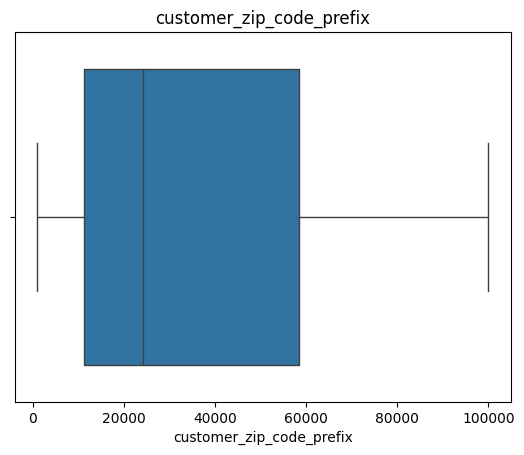

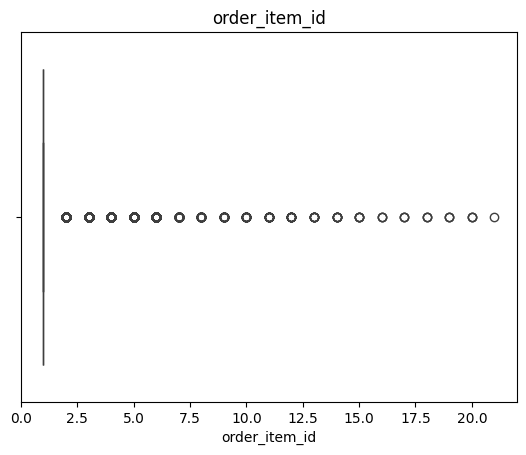

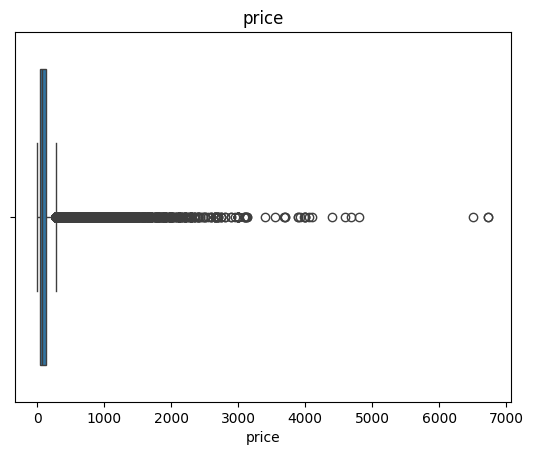

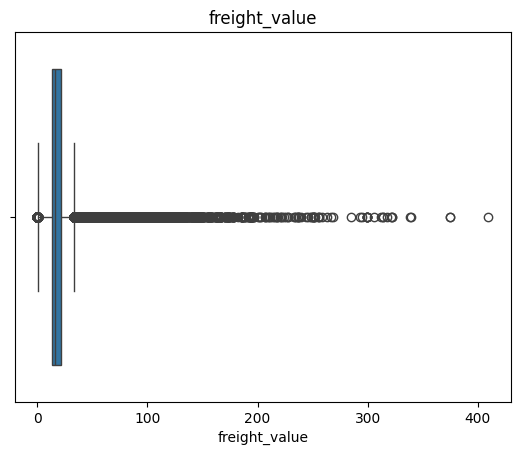

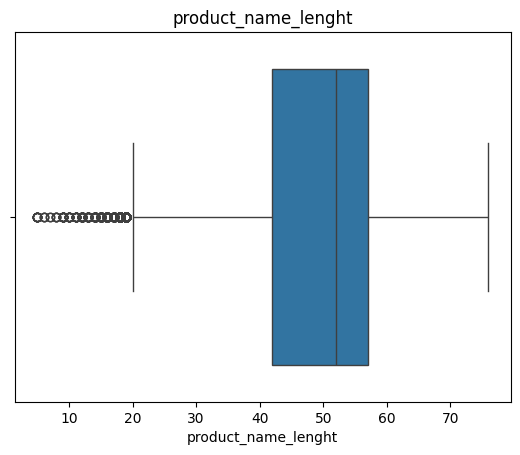

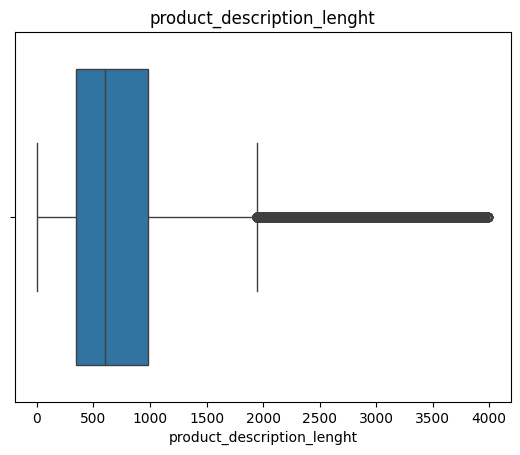

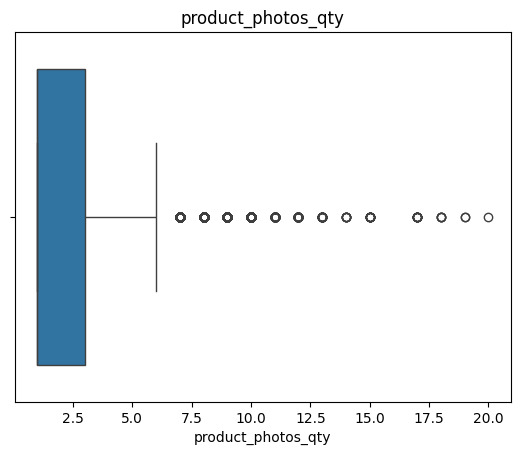

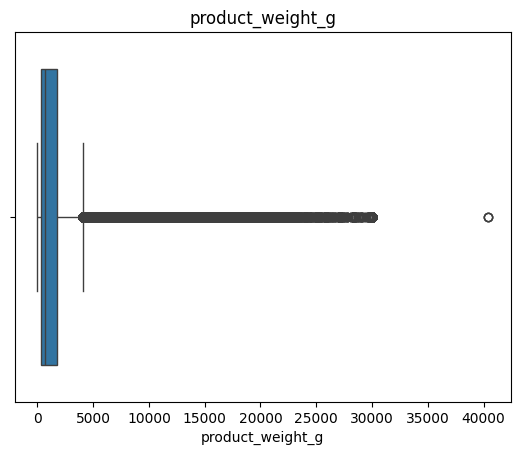

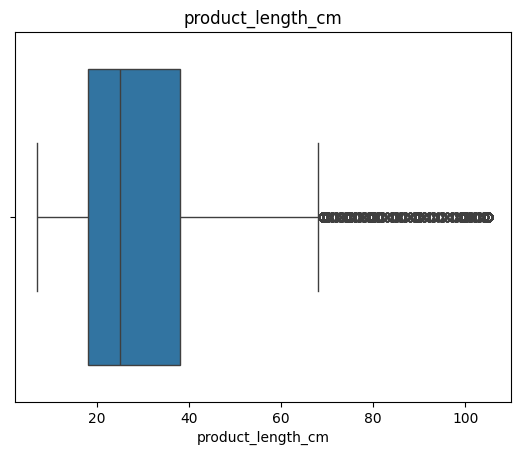

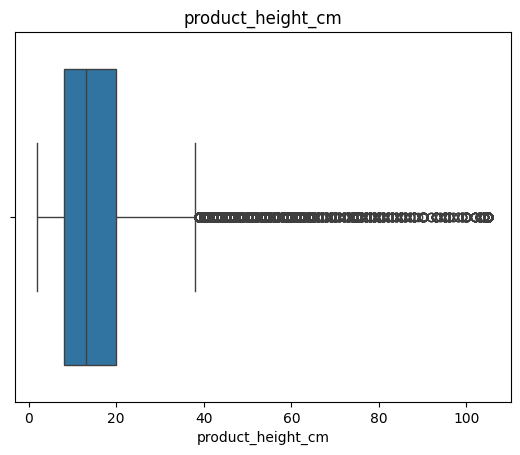

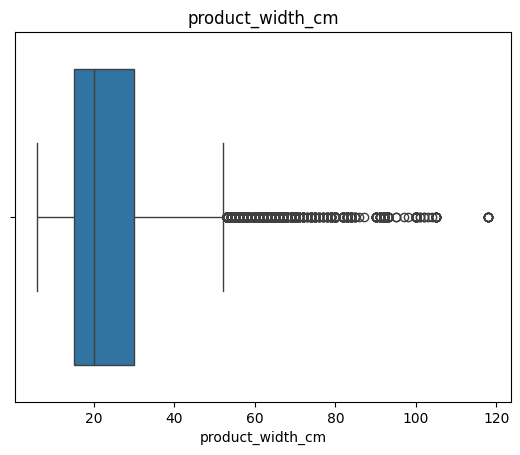

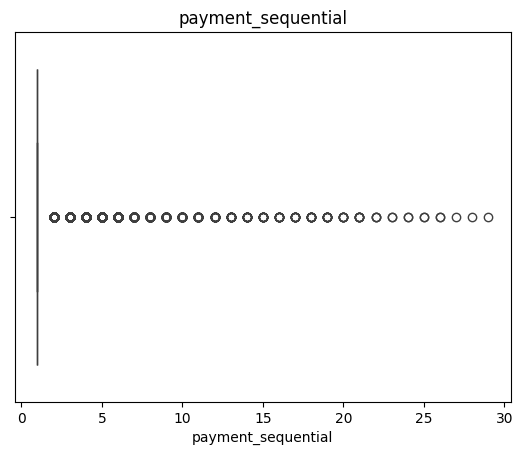

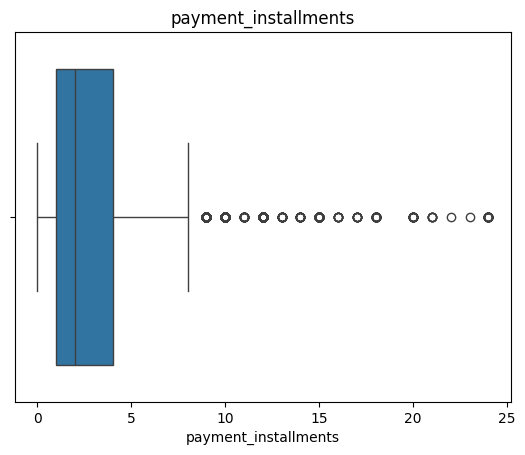

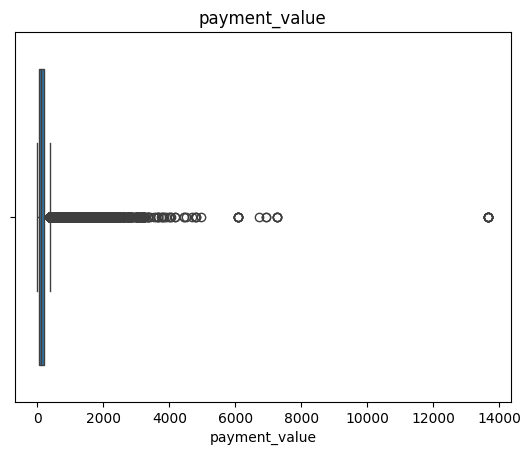

In [18]:
#Cek Kolom yang terdapat Outlier menggunakan box plot
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [19]:
#Ubah Tipe data menjadi datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [20]:
df[df['order_delivered_customer_date'] < df['order_purchase_timestamp']]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,product_category_name_english


In [21]:
df[df['payment_value'] < 0]
df[df['product_weight_g'] <= 0]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,product_category_name_english
6055,06afc1144eb9f51ef2aa90ec9223c7f4,e8be078dee76002545a9c5f10b7d7c4e,delivered,2018-08-15 17:13:07,2018-08-15 17:25:20,2018-08-16 14:44:00,2018-08-24 22:54:42,2018-09-20,eb8ba0e91b822fefb8d7f0243881647d,89930,...,1.0,0.0,30.0,25.0,30.0,1.0,credit_card,10.0,307.22,bed_bath_table
6056,06afc1144eb9f51ef2aa90ec9223c7f4,e8be078dee76002545a9c5f10b7d7c4e,delivered,2018-08-15 17:13:07,2018-08-15 17:25:20,2018-08-16 14:44:00,2018-08-24 22:54:42,2018-09-20,eb8ba0e91b822fefb8d7f0243881647d,89930,...,1.0,0.0,30.0,25.0,30.0,1.0,credit_card,10.0,307.22,bed_bath_table
15179,4abc7b5330425bcf9c2f7f48151a88c0,d1568f1104d2015dc70bdf7d9ab88dd2,delivered,2018-07-31 21:05:49,2018-07-31 21:40:18,2018-08-01 16:00:00,2018-08-07 23:56:48,2018-08-17,93b52b7591ca73fc44cdac70146a1b0d,4904,...,1.0,0.0,30.0,25.0,30.0,1.0,credit_card,6.0,144.39,bed_bath_table
46797,200b121c28e10ef638131a7c76753327,26bcca10e5c9679c306d8333bf527929,delivered,2018-08-04 15:55:59,2018-08-04 16:10:16,2018-08-08 14:35:00,2018-08-23 18:21:59,2018-08-30,7e518b9896c26844bf24c1802c7d8775,75830,...,1.0,0.0,30.0,25.0,30.0,1.0,credit_card,1.0,119.89,bed_bath_table
77602,476b812a7e4fc972646eb390517bddcb,18a1176652a9344ba489fa4ccaa3c20f,delivered,2018-08-18 11:09:12,2018-08-18 11:30:54,2018-08-21 12:07:00,2018-08-30 16:56:44,2018-09-12,387207b587c829c6678a03c8b711ae1e,72911,...,1.0,0.0,30.0,25.0,30.0,1.0,credit_card,4.0,153.61,bed_bath_table
108918,b489f7ae130ba3fd26b0a20f8cc81c61,99411e9599f8b7a90f2a362b874b66ca,delivered,2018-08-18 20:37:22,2018-08-18 20:49:57,2018-08-20 14:20:00,2018-08-27 14:52:02,2018-09-04,aaa0fa0d6f239f72e8067326c6a134fa,96360,...,1.0,0.0,30.0,25.0,30.0,1.0,credit_card,6.0,153.61,bed_bath_table
116773,06d9e69034388abf6da64378e10737b8,afef0047e43944e8c6630ec0d0f7de2e,delivered,2018-07-30 10:42:40,2018-07-31 09:10:11,2018-07-31 14:24:00,2018-08-09 22:18:29,2018-09-10,7dff353845a1d77a928dcb952c6bc966,45653,...,1.0,0.0,30.0,25.0,30.0,1.0,credit_card,4.0,247.70,bed_bath_table
116774,06d9e69034388abf6da64378e10737b8,afef0047e43944e8c6630ec0d0f7de2e,delivered,2018-07-30 10:42:40,2018-07-31 09:10:11,2018-07-31 14:24:00,2018-08-09 22:18:29,2018-09-10,7dff353845a1d77a928dcb952c6bc966,45653,...,1.0,0.0,30.0,25.0,30.0,1.0,credit_card,4.0,247.70,bed_bath_table


**Insight:**
- Dataset memiliki jumlah missing values yang cukup signifikan, terutama pada atribut produk dan pengiriman seperti product_category_name, product_description_lenght, serta order_delivered_customer_date. Hal ini menunjukkan bahwa tidak semua transaksi memiliki informasi produk dan status pengiriman yang lengkap.
- Ditemukan banyak outlier pada fitur dimensi dan berat produk seperti product_weight_g, product_length_cm, dan product_height_cm. Outlier ini dapat mempengaruhi analisis statistik dan perlu ditangani sebelum dilakukan eksplorasi lebih lanjut.

### Cleaning Data

In [25]:
#Menangani Missing Values
df = df.dropna(subset=['product_category_name'])
df = df.dropna(subset=['product_category_name_english'])
df['product_weight_g'].fillna(df['product_weight_g'].median(), inplace=True)
df['product_length_cm'].fillna(df['product_length_cm'].median(), inplace=True)
df['product_height_cm'].fillna(df['product_height_cm'].median(), inplace=True)
df['product_width_cm'].fillna(df['product_width_cm'].median(), inplace=True)
df = df.dropna(subset=['price', 'freight_value'])
df = df.dropna(subset=['payment_type'])
df = df.dropna(subset=['product_id', 'seller_id'])

/tmp/ipykernel_1103/112863091.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['product_weight_g'].fillna(df['product_weight_g'].median(), inplace=True)
/tmp/ipykernel_1103/112863091.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

In [26]:
df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,14
order_delivered_carrier_date,1205
order_delivered_customer_date,2495
order_estimated_delivery_date,0
customer_unique_id,0
customer_zip_code_prefix,0


In [27]:
#Membersihkan Kategori yang tidak sesuai
df['payment_type'] = df['payment_type'].replace('not_defined', None)


In [28]:
#capping outlier
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)
    return df
cols = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'price',
    'freight_value'
]

for col in cols:
    df = cap_outliers(df, col)

In [46]:
df.to_csv('main_data_clean.csv', index=False)

**Insight:**
- Setelah proses cleaning, ditemukan bahwa cukup banyak data produk yang sebelumnya tidak lengkap (missing values pada kategori, dimensi, dan berat). Hal ini menunjukkan bahwa kualitas data pada bagian atribut produk awalnya kurang baik dan berpotensi mempengaruhi analisis.
- Ditemukan banyak outlier pada variabel seperti berat, dimensi, harga, dan ongkir. Setelah dilakukan penanganan menggunakan metode capping, distribusi data menjadi lebih stabil dan representatif terhadap kondisi umum transaksi.

## Exploratory Data Analysis (EDA)

### Explore ...

<Axes: xlabel='year_month'>

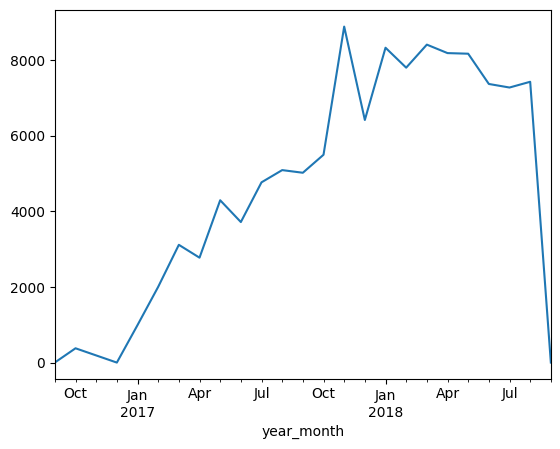

In [30]:
#Analisis Transaksi


df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')

df.groupby('year_month')['order_id'].count().plot()

In [31]:
#Status Order
df['order_status'].value_counts()

,count
order_status,
delivered,113384
shipped,1214
canceled,549
processing,362
invoiced,359
unavailable,7
approved,3


In [32]:
#Metode Pembayaran
df['payment_type'].value_counts()

,count
payment_type,
credit_card,85523
boleto,22542
voucher,6155
debit_card,1658


In [34]:
#Analisis Produk
df['product_category_name_english'].value_counts().head(10)

,count
product_category_name_english,
bed_bath_table,11823
health_beauty,9972
sports_leisure,8945
furniture_decor,8744
computers_accessories,8082
housewares,7355
watches_gifts,6201
telephony,4721
garden_tools,4574


In [35]:
#Analisis Revenue
df.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)

,price
product_category_name_english,
bed_bath_table,1055708.94
health_beauty,1029704.60
watches_gifts,884923.26
sports_leisure,879597.67
computers_accessories,802920.98
furniture_decor,730380.16
housewares,597621.62
cool_stuff,535352.38
auto,472756.57


In [36]:
#Lokasi Customer
df['customer_state'].value_counts()

,count
customer_state,
SP,48838
RJ,15089
MG,13451
RS,6384
PR,5882
SC,4237
BA,3974
DF,2440
GO,2375


In [37]:
#Performa Delivery
df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

df['delivery_time'].describe()

,delivery_time
count,113383.000000
mean,12.015831
std,9.451101
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


In [38]:
df['late_delivery'] = df['order_delivered_customer_date'] > df['order_estimated_delivery_date']

df['late_delivery'].value_counts()

,count
late_delivery,
False,107002
True,8876


In [39]:
#Korelasi
df[['price','freight_value','product_weight_g']].corr()

,price,freight_value,product_weight_g
price,1.000000,0.433419,0.436142
freight_value,0.433419,1.000000,0.506910
product_weight_g,0.436142,0.506910,1.000000


**Insight:**
- Terjadi pertumbuhan bisnis yang kuat dari 2017 ke 2018, menunjukkan peningkatan adopsi platform oleh customer. Namun, penurunan tajam di akhir periode kemungkinan disebabkan oleh data yang belum lengkap (cut-off data), bukan penurunan performa bisnis.
- Mayoritas pesanan berhasil diselesaikan (delivered), menunjukkan performa operasional yang sangat baik dengan tingkat pembatalan yang rendah. Hal ini mengindikasikan sistem fulfillment dan logistik berjalan dengan efektif.
- Customer sangat dominan menggunakan credit card sebagai metode pembayaran utama, menunjukkan preferensi terhadap transaksi instan dan digital. Namun, metode boleto masih memiliki porsi signifikan, yang menandakan adanya segmen customer yang belum sepenuhnya mengadopsi pembayaran digital
- Kategori bed_bath_table tidak hanya memiliki volume tinggi tetapi juga menghasilkan revenue terbesar, menjadikannya kategori paling strategis. Selain itu, kategori watches_gifts menunjukkan nilai transaksi tinggi meskipun volumenya tidak sebesar kategori lain, mengindikasikan produk dengan harga lebih mahal
- Sebagian besar pengiriman dilakukan tepat waktu, namun masih terdapat sekitar 7–8% keterlambatan. Hal ini menunjukkan bahwa meskipun sistem logistik cukup baik, masih ada ruang untuk perbaikan dalam ketepatan pengiriman.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang paling berkontribusi terhadap revenue?

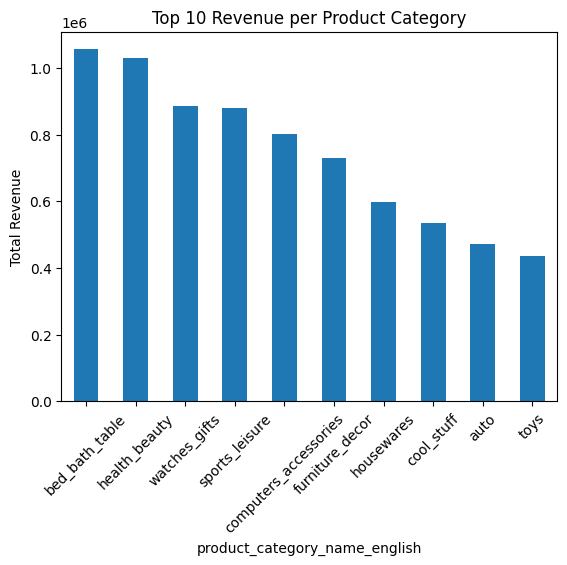

In [44]:
top_revenue = df.groupby('product_category_name_english')['price'] \
                .sum() \
                .sort_values(ascending=False) \
                .head(10)

top_revenue.plot(kind='bar')
plt.title('Top 10 Revenue per Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

**Insight:**
- Kategori bed_bath_table dan health_beauty merupakan penyumbang revenue terbesar dalam platform. Hal ini menunjukkan bahwa kebutuhan rumah tangga dan perawatan diri menjadi sumber pendapatan utama. Selain itu, kategori seperti watches_gifts memiliki revenue tinggi meskipun tidak termasuk kategori dengan jumlah transaksi terbanyak, yang mengindikasikan adanya produk dengan nilai jual tinggi (high-value products).


### Pertanyaan 2: Bagaimana performa pengiriman dan apakah banyak keterlambatan?

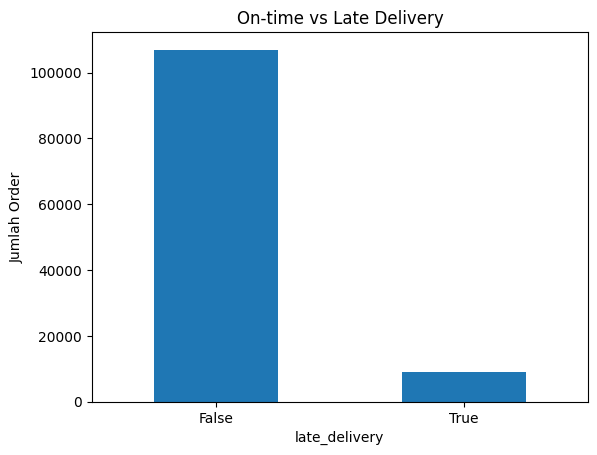

In [45]:
#Visualisasi
df['late_delivery'].value_counts().plot(kind='bar')
plt.title('On-time vs Late Delivery')
plt.ylabel('Jumlah Order')
plt.xticks(rotation=0)
plt.show()

**Insight:**
- Sebagian besar pengiriman dilakukan tepat waktu, namun masih terdapat sekitar 7–8% pesanan yang mengalami keterlambatan. Meskipun proporsi keterlambatan relatif kecil, jumlah absolutnya cukup signifikan sehingga dapat berdampak pada kepuasan pelanggan.

## Analisis Lanjutan (Opsional)

## Conclusion

- Kategori bed_bath_table dan health_beauty merupakan kontributor utama terhadap total revenue platform, baik dari sisi jumlah transaksi maupun nilai penjualan. Selain itu, kategori seperti watches_gifts juga menunjukkan kontribusi revenue yang tinggi meskipun volumenya tidak sebesar kategori lain, yang mengindikasikan adanya produk dengan harga lebih tinggi. Hal ini menunjukkan bahwa strategi bisnis dapat difokuskan pada kategori dengan volume tinggi serta kategori dengan nilai transaksi besar untuk memaksimalkan pendapatan.
- Secara keseluruhan, performa pengiriman tergolong baik dengan mayoritas pesanan berhasil dikirim tepat waktu. Namun, masih terdapat sekitar 7–8% pesanan yang mengalami keterlambatan. Meskipun persentasenya relatif kecil, jumlah tersebut cukup signifikan dan berpotensi mempengaruhi kepuasan pelanggan. Oleh karena itu, diperlukan peningkatan pada efisiensi logistik untuk mengurangi keterlambatan dan meningkatkan kualitas layanan.